In [8]:
from classy import Class
import numpy as np
# -2

ImportError: dlopen(/Users/zhiyulu/Install/anaconda3/lib/python3.11/site-packages/classy-2.7.2-py3.11-macosx-11.0-arm64.egg/classy.cpython-311-darwin.so, 0x0002): symbol not found in flat namespace '_gsl_set_error_handler_off'

In [6]:
Class?

Object `Class` not found.


In [67]:
samples = np.random.uniform(low=[-1.3, -1.5, -1.], high=[-0.5, 0.5, 0.05], size=(10000, 3)) # w0, wa, alpha_B

In [13]:
samples = np.random.uniform(low=[-1.3, -1.5, -1.], high=[-0.5, 0.5, 0.05], size=(10000, 3)) # w0, wa, alpha_B
M = Class()
cosmo={'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842}
M.set(cosmo)
ok, _cs, _alpha_B = [], [], []
for s in [(-0.8,-0.75,0.5)]: 
    w0, wa, _gamma_B = s
    hiset={
            'Omega_smg':-1,
            'Omega_fld':0,
            'Omega_Lambda':0,
            'gravity_model':'propto_omega',
            'parameters_smg':f'0.,{_gamma_B},0.,0.,1.',
            'expansion_model':'w0wa',
            'expansion_smg':f'0.7,{w0},{wa}',
            # 'expansion_model':'lcdm',
            # 'expansion_smg':'0.7',
            'skip_stability_tests_smg':'n',
            # 'cs2_safe_smg':10.,
            #'D_safe_smg':1e-14,
            # 'ct2_safe_smg':10.,
            # 'M2_safe_smg':10.,
            'method_qs_smg':'automatic'
        }
    M.set(hiset)
    try:
        M.compute()
        #print('ok',s)
        cs = np.mean(M.get_background()['c_s^2'])
        ok.append(s)
        _cs.append(cs)
        _alpha_B.append(alpha_B)
    except:
        pass
        
ok, _cs, _alpha_B = np.array(ok), np.array(_cs), np.array(_alpha_B)
print (np.mean(_cs), np.std(_cs))
kin_D = M.get_background()['kin (D)']


1.0 0.0


{'z': array([1.00000000e+14, 9.99194400e+13, 9.98389448e+13, ...,
        1.61314959e-03, 8.06249775e-04, 0.00000000e+00]),
 'proper time [Gyr]': array([7.55951851e-26, 7.57171315e-26, 7.58392746e-26, ...,
        1.36771999e+01, 1.36888116e+01, 1.37004295e+01]),
 'conf. time [Mpc]': array([4.63478500e-09, 4.63842298e-09, 4.64387995e-09, ...,
        1.41389201e+04, 1.41424846e+04, 1.41460481e+04]),
 'H [1/Mpc]': array([2.15725629e+22, 2.15378192e+22, 2.15031314e+22, ...,
        2.26434905e-04, 2.26312337e-04, 2.26189813e-04]),
 'comov. dist.': array([1.41460481e+04, 1.41460481e+04, 1.41460481e+04, ...,
        7.12797844e+00, 3.56351800e+00, 0.00000000e+00]),
 'ang.diam.dist.': array([1.41460481e-10, 1.41574534e-10, 1.41688678e-10, ...,
        7.11649847e+00, 3.56064723e+00, 0.00000000e+00]),
 'lum. dist.': array([1.41460481e+18, 1.41346521e+18, 1.41232652e+18, ...,
        7.13947694e+00, 3.56639109e+00, 0.00000000e+00]),
 'comov.snd.hrz.': array([2.67631746e-09, 2.67847525e-09, 2.

In [3]:
M = Class()
cosmo={'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842}
M.set(cosmo)
ok, _cs, _alpha_B = [], [], []
for s in samples: 
    w0, wa, _gamma_B = s
    hiset={
            'Omega_smg':-1,
            'Omega_fld':0,
            'Omega_Lambda':0,
            'gravity_model':'propto_omega',
            'parameters_smg':f'0.,{_gamma_B},0.,0.,1.',
            'expansion_model':'w0wa',
            'expansion_smg':f'0.7,{w0},{wa}',
            # 'expansion_model':'lcdm',
            # 'expansion_smg':'0.7',
            'skip_stability_tests_smg':'n',
            # 'cs2_safe_smg':10.,
            #'D_safe_smg':1e-14,
            # 'ct2_safe_smg':10.,
            # 'M2_safe_smg':10.,
            'method_qs_smg':'automatic'
        }
    M.set(hiset)
    try:
        M.compute()
        #print('ok',s)
        cs = np.mean(M.get_background()['c_s^2'])
        ok.append(s)
        _cs.append(cs)
        _alpha_B.append(alpha_B)
    except:
        pass
        
ok, _cs, _alpha_B = np.array(ok), np.array(_cs), np.array(_alpha_B)
print (np.mean(_cs), np.std(_cs))

1.0 0.0


In [10]:
M.Omega_m()

0.3098830430481206

In [51]:
# np.savetxt('stable_parameter_space_of_w0wa_from_hiclass.txt',ok)
ok = np.loadtxt('stable_parameter_space_of_w0wa_from_hiclass.txt')

In [5]:
import matplotlib.pyplot as plt

Text(0, 0.5, '$w_a$')

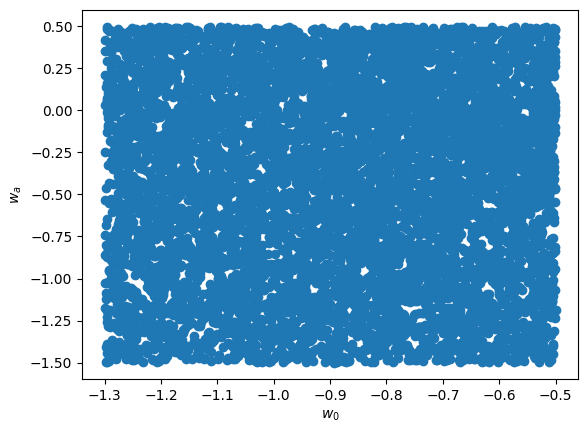

In [52]:
plt.scatter(ok[:,0], ok[:,1])
plt.xlabel(r'$w_0$')
plt.ylabel(r'$w_a$')

In [63]:
from getdist import loadMCSamples, plots, MCSamples
import os
def load_chain(chainname, basedir='./', truth=None):
    chains = os.path.join(basedir, chainname)
    print(chains)
    samples = loadMCSamples(chains, settings={'ignore_rows': 0.5});
    if truth is not None: get_relative_posteriors(samples, truth)
    return samples
alpha_chain = load_chain('2025-01-04_10000000_', 
                         '/Users/zhiyulu/Downloads/hiclass_EFTofBOSS_pk_bk_Planck_extBAO_PanPlus_w0wa_exacttime/chain')
p = alpha_chain.getParams()
alpha_chain.addDerived(p.expansion_smg__2, name='w0_fld', label=r'w_0')
alpha_chain.addDerived(p.expansion_smg__3, name='wa_fld', label=r'w_a')
alpha_chain.addDerived(p.parameters_smg__2 , name='alpha_B', label=r'\alpha_B^0')


/Users/zhiyulu/Downloads/hiclass_EFTofBOSS_pk_bk_Planck_extBAO_PanPlus_w0wa_exacttime/chain/2025-01-04_10000000_


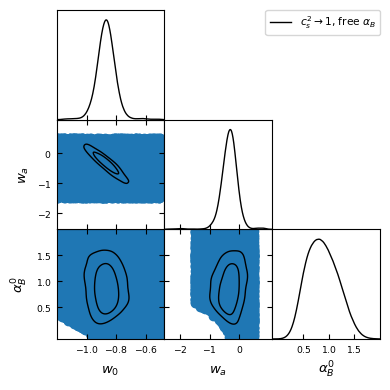

In [65]:

g = plots.get_subplot_plotter(width_inch=4) 
cosmo = ['w0_fld', 'wa_fld', 'alpha_B']
g.triangle_plot([alpha_chain], cosmo, filled=False, 
                contour_lws=[1., 1., 1., 1.],  
                legend_labels=[r'$c_s^2 \rightarrow 1$, free $\alpha_B$'],
                # title_limit=1,
               )
g.subplots[1][0].scatter(ok[:,0], ok[:,1])
g.subplots[2][0].scatter(ok[:,0], ok[:,2])
g.subplots[2][1].scatter(ok[:,1], ok[:,2])

Text(0, 0.5, '$\\gamma_B$')

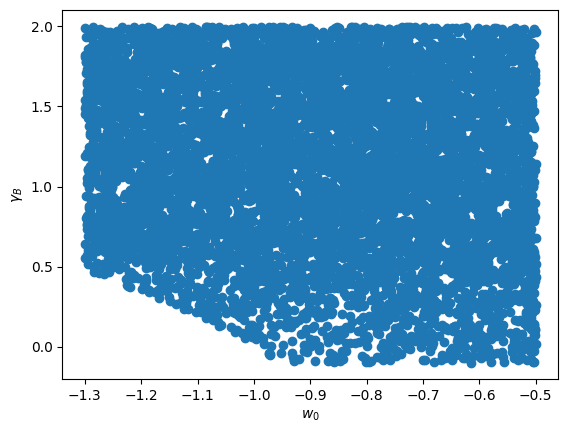

In [54]:
plt.scatter(ok[:,0], ok[:,2])
plt.xlabel(r'$w_0$')
plt.ylabel(r'$\gamma_B$')

Text(0, 0.5, '$\\gamma_B$')

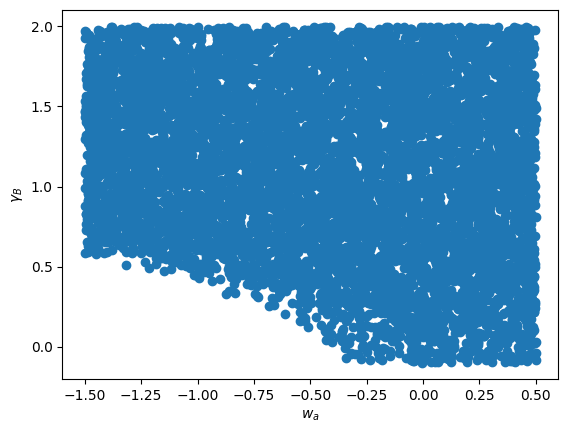

In [55]:
plt.scatter(ok[:,1], ok[:,2])
plt.xlabel(r'$w_a$')
plt.ylabel(r'$\gamma_B$')